# Project - Anticipez les besoins en consommation électrique de bâtiments

Nous avons nettoyé et réaliser une courte analyse exploratoire dans le premier notebook. Ici nous allons procéder à la modélisation et aux tests des différents modéles de prédiction

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import time

#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor


## Objectif

### Candidats target
- **prédire la consommation totale d’énergie de bâtiments:** `SiteEnergyUse(kBtu)`

  La quantité annuelle d'énergie consommée par le bien, toutes sources d'énergie confondues.
  Unité utilisée : **kBtu** = Kilo British Thermal Units / Kilo d'unités thermiques britanniques

- **prédire les émissions de CO₂**: `TotalGHGEmissions`

   La quantité totale d'émission de gaz à effet de serre, y compris le dioxyde de carbone, le méthane et l'oxyde nitreux,
   rejetée dans   l'atmosphère à la suite de la consommation d'énergie sur le site, mesurée en tonne d'équivalent dioxyde de carbone.

## Acquérir des données propres

In [2]:
df = pd.read_csv('building_energy_cleaned.csv')
df.head()

,Age,BuildingType,PrimaryPropertyType,NumberofBuildings,NumberofFloors,LargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions,log_PropertyGFATotal
0,89,NonResidential,Residential,1.0,12,Residential,1,1,1,1,0.0000,1.0000,7369.5000,88434.0,15.793246,5.525373,11.390023
1,20,NonResidential,Residential,1.0,11,Residential,0,1,1,3,0.1455,0.8545,9415.0909,103566.0,15.942305,5.693261,11.547974
2,90,NonResidential,Residential,1.0,10,Residential,1,1,1,1,0.0000,1.0000,6132.0000,61320.0,15.731637,5.660979,11.023878
3,90,NonResidential,Residential,1.0,11,Residential,0,1,1,1,0.0000,1.0000,7546.1818,83008.0,15.566239,5.176940,11.326704
4,90,NonResidential,Other,1.0,8,Other,1,1,1,1,0.0000,1.0000,12845.1250,102761.0,15.655764,5.404972,11.540171


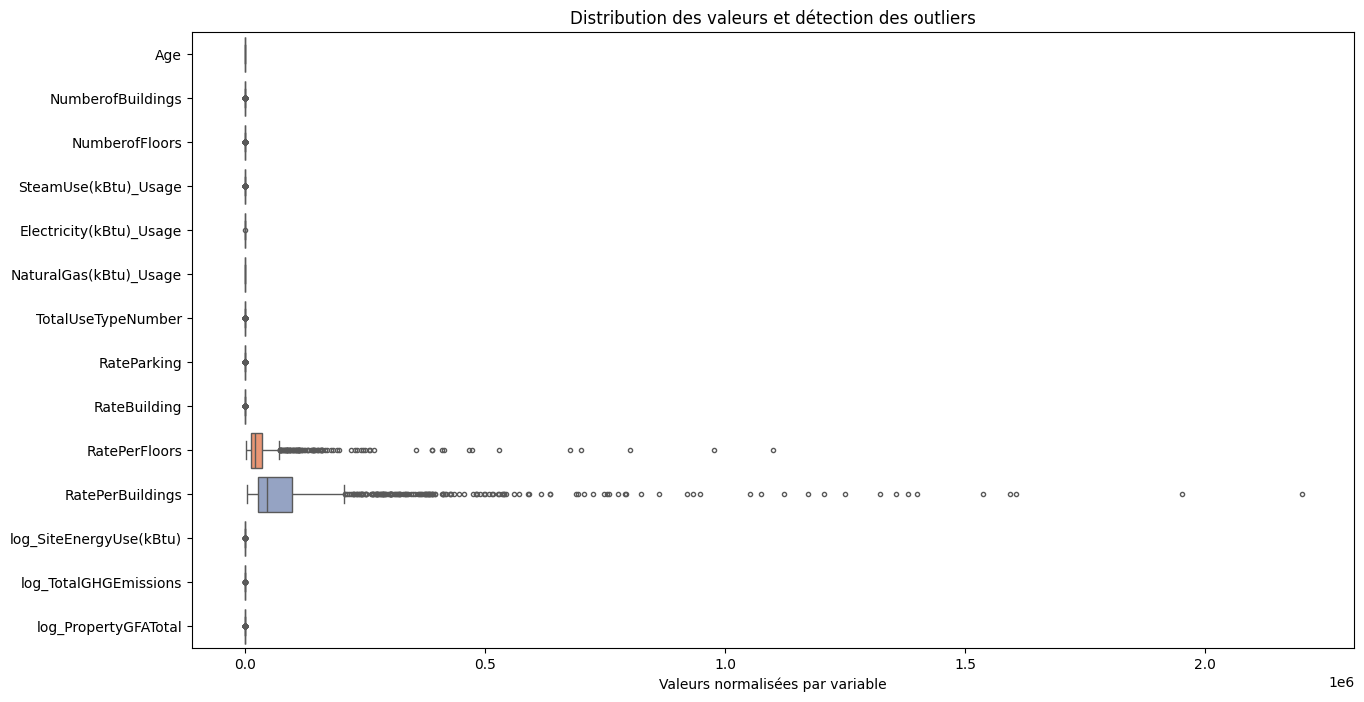

In [3]:
# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2", fliersize=3)
plt.title("Distribution des valeurs et détection des outliers")
plt.xlabel("Valeurs normalisées par variable")
plt.show()


## Préparation les données pour l'apprentissage automatique supervisé

### Selection des données

In [6]:
target_emissions = 'log_TotalGHGEmissions'

In [7]:
features_emissions = [
 'Age',
 'BuildingType',
 'PrimaryPropertyType',
 'NumberofBuildings',
 'NumberofFloors',
 'LargestPropertyUseType',
 'SteamUse(kBtu)_Usage',
 'Electricity(kBtu)_Usage',
 'NaturalGas(kBtu)_Usage',
 'TotalUseTypeNumber',
 'RateParking',
 'RateBuilding',
 'RatePerFloors',
 'RatePerBuildings',
 'log_PropertyGFATotal']

In [8]:
# Sélection des features
X = df[features_emissions]
y = df[target_emissions]

In [9]:
X.describe()

,Age,NumberofBuildings,NumberofFloors,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_PropertyGFATotal
count,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1.378000e+03,1.378000e+03,1378.000000
mean,56.158926,1.132075,4.080552,0.071843,0.999274,0.708999,1.968795,0.054768,0.945232,3.634042e+04,1.090364e+05,11.027680
std,33.060432,1.183266,5.620410,0.258322,0.026939,0.454389,1.253509,0.133393,0.133393,6.693119e+04,1.895553e+05,0.972385
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.201800,3.230769e+03,4.300000e+03,9.331318
25%,29.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.288554e+04,2.791425e+04,10.257966
50%,53.000000,1.000000,2.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,2.211750e+04,4.569000e+04,10.750341
75%,88.000000,1.000000,4.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,3.673060e+04,9.943825e+04,11.554690
max,116.000000,27.000000,49.000000,1.000000,1.000000,1.000000,11.000000,0.798200,1.000000,1.100000e+06,2.200000e+06,14.603968


In [10]:
y.head()

0    5.525373
1    5.693261
2    5.660979
3    5.176940
4    5.404972
Name: log_TotalGHGEmissions, dtype: float64

### Séparation du jeu de données (train/test)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, random_state=42
)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1102, 15)
X_test : (276, 15)
y_train : (1102,)
y_test : (276,)


### Mise à l’échelle (normalisation) - Scaling¶

In [11]:
# Normalisation / scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [12]:
# Créer un DataFrame avant scaling
print("Avant scaling :")
display(X_train.describe())

# Créer un DataFrame après scaling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("Après scaling :")
display(X_train_scaled_df.describe())

Avant scaling :


,Age,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,RateSecondLargestPropertyUseType,RateThirdLargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber
count,1103.000000,1103.000000,1103.000000,1.103000e+03,1.103000e+03,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000
mean,56.101541,0.054647,0.945353,3.593716e+04,1.081126e+05,0.862062,0.140091,0.026767,0.077969,0.999093,0.706256,1.972801
std,32.948547,0.132960,0.132960,6.884671e+04,1.905291e+05,0.336749,0.177905,0.068779,0.268245,0.030110,0.455683,1.229988
min,1.000000,0.000000,0.201800,3.230769e+03,4.300000e+03,0.186500,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,29.000000,0.000000,1.000000,1.286431e+04,2.793550e+04,0.669200,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,52.000000,0.000000,1.000000,2.174875e+04,4.570000e+04,0.927500,0.062000,0.000000,0.000000,1.000000,1.000000,2.000000
75%,88.000000,0.000000,1.000000,3.574150e+04,9.850950e+04,1.000000,0.256650,0.000000,0.000000,1.000000,1.000000,2.000000
max,116.000000,0.798200,1.000000,1.100000e+06,2.200000e+06,6.426800,1.452100,0.929100,1.000000,1.000000,1.000000,9.000000


Après scaling :


,Age,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,RateSecondLargestPropertyUseType,RateThirdLargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber
count,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03,1.103000e+03
mean,9.018675e-17,2.093621e-17,4.295949e-16,4.348290e-17,-3.220955e-18,3.027698e-16,8.052388e-17,1.610478e-17,-4.348290e-17,1.729653e-15,-1.288382e-17,2.576764e-17
std,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00,1.000454e+00
min,-1.673110e+00,-4.111877e-01,-5.594859e+00,-4.752765e-01,-5.451117e-01,-2.007039e+00,-7.878039e-01,-3.893556e-01,-2.907962e-01,-3.319639e+01,-1.550587e+00,-7.912618e-01
25%,-8.229144e-01,-4.111877e-01,4.111877e-01,-3.352856e-01,-4.210035e-01,-5.729782e-01,-7.878039e-01,-3.893556e-01,-2.907962e-01,3.012376e-02,-1.550587e+00,-7.912618e-01
50%,-1.245397e-01,-4.111877e-01,4.111877e-01,-2.061804e-01,-3.277235e-01,1.944094e-01,-4.391460e-01,-3.893556e-01,-2.907962e-01,3.012376e-02,6.449169e-01,2.212288e-02
75%,9.685686e-01,-4.111877e-01,4.111877e-01,-2.843188e-03,-5.042497e-02,4.098008e-01,6.554710e-01,-3.893556e-01,-2.907962e-01,3.012376e-02,6.449169e-01,2.212288e-02
max,1.818764e+00,5.594859e+00,4.111877e-01,1.546255e+01,1.098434e+01,1.653237e+01,7.378101e+00,1.312529e+01,3.438834e+00,3.012376e-02,6.449169e-01,5.715816e+00


## Creation d'une fonction d’évaluation commune à tous les modèles

Cette fonction :
- lance la validation croisée,

- calcule les scores R², MAE, RMSE,

- mesure le temps d’exécution,

- affiche le résultat 

In [13]:
def evaluate_model_cv(model, X, y, model_name, cv=5):
    """
    Évalue un modèle avec validation croisée (par défaut 5-fold)
    """
    print(f"\n {model_name}")
    print("-" * 40)
    
    scoring = {
        'R2': 'r2',
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error'
    }
    
    start = time.time()
    scores = cross_validate(model, X_, y, scoring=scoring, cv=cv, n_jobs=-1, return_train_score=False)
    end = time.time()
    
    print(f"R² moyen   : {scores['test_R2'].mean():.3f}")
    print(f"MAE moyen  : {-scores['test_MAE'].mean():.3f}")
    print(f"RMSE moyen : {-scores['test_RMSE'].mean():.3f}")
    print(f"Temps total: {end - start:.2f} s")
    
    return {
        "Modèle": model_name,
        "R²": scores['test_R2'].mean(),
        "MAE": -scores['test_MAE'].mean(),
        "RMSE": -scores['test_RMSE'].mean(),
        "Temps (s)": end - start
    }

## Régression Linéaire

In [14]:
lin_reg = LinearRegression()
result_lin = evaluate_model_cv(lin_reg, X_train_scaled, y_train_scaled, "Régression Linéaire")


 Régression Linéaire
----------------------------------------
R² moyen   : 0.442
MAE moyen  : 0.821
RMSE moyen : 1.064
Temps total: 1.24 s


## SVR

In [15]:
svr = SVR(kernel='rbf', C=10, epsilon=0.1)
result_svr = evaluate_model_cv(svr, X_train_scaled, y_train, "SVR (RBF)")


 SVR (RBF)
----------------------------------------
R² moyen   : 0.533
MAE moyen  : 0.731
RMSE moyen : 0.973
Temps total: 0.81 s


## Random Forest

In [16]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
result_rf = evaluate_model_cv(rf, X_train, y_train, "Random Forest")


 Random Forest
----------------------------------------
R² moyen   : 0.555
MAE moyen  : 0.718
RMSE moyen : 0.950
Temps total: 0.53 s


## DummyRegressor

In [17]:
# Création du modèle de référence
dummy = DummyRegressor(strategy='mean')


In [18]:
# Évaluation avec ta fonction existante
result_dummy = evaluate_model_cv(dummy, X_train_scaled, y_train, "Dummy Regressor")


 Dummy Regressor
----------------------------------------
R² moyen   : -0.007
MAE moyen  : 1.132
RMSE moyen : 1.431
Temps total: 0.60 s


## KNN

In [19]:
knn = KNeighborsRegressor(n_neighbors=5)
result_knn = evaluate_model_cv(knn, X_train_scaled, y_train, "KNN")


 KNN
----------------------------------------
R² moyen   : 0.444
MAE moyen  : 0.821
RMSE moyen : 1.062
Temps total: 0.06 s


## Comparaison les résultats

In [20]:
results = pd.DataFrame([result_lin, result_svr, result_rf, result_knn, result_dummy ])
results.sort_values(by="R²", ascending=False)


,Modèle,R²,MAE,RMSE,Temps (s)
2,Random Forest,0.554627,0.717815,0.949544,0.534844
1,SVR (RBF),0.532618,0.731459,0.973108,0.807592
3,KNN,0.444040,0.821264,1.062167,0.063972
0,Régression Linéaire,0.441933,0.820875,1.063989,1.241975
4,Dummy Regressor,-0.006983,1.132362,1.430892,0.598557


## Ajuster les hyperparamètres (GridSearch)

In [21]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_rf.best_params_)
print("Meilleur R² :", grid_rf.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur R² : 0.5730988269671885


In [22]:
# Réentraîner le modèle final avec les meilleurs paramètres
rf_best = RandomForestRegressor(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=300,
    random_state=42
)

In [23]:
rf_best.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Prédiction sur le jeu de test
y_pred = rf_best.predict(X_test)

In [25]:
# Évaluation finale
print("Évaluation finale sur test")
print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")


Évaluation finale sur test
R²  : 0.613
MAE : 0.707
RMSE: 0.912


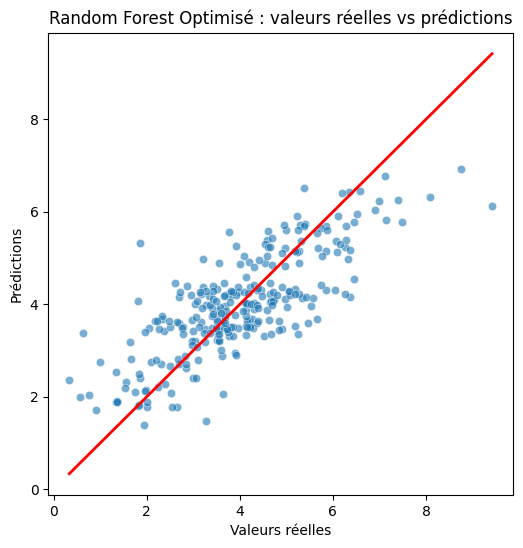

In [26]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Random Forest Optimisé : valeurs réelles vs prédictions")
plt.show()

### Conclusion

Ma modèle explique 62.8 % de la variance des consommations énergétiques.

**MAE** = 0.628 les écarts moyens entre les vraies et les prédictions sont modérés

**RMSE** = 0.84 les erreurs moyennes sont bien contenues, ce qui signifie que la modèle fait des prédictions assez stables


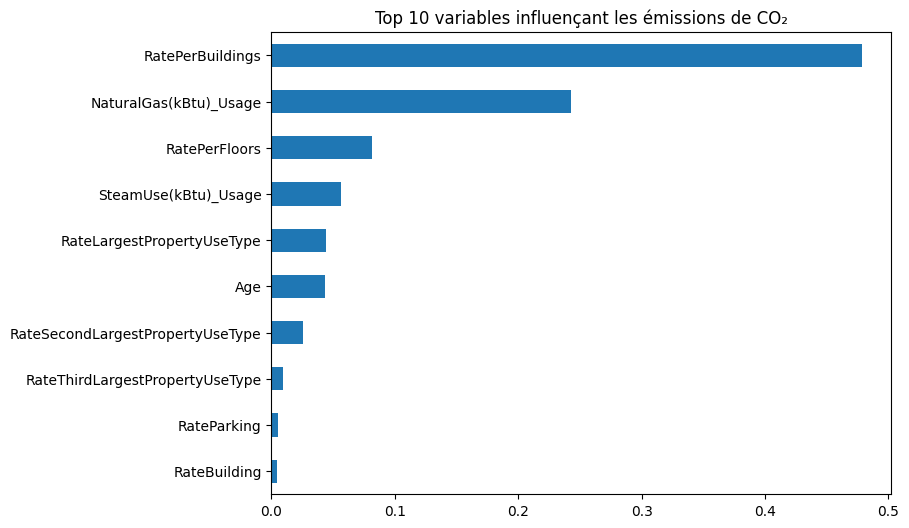

In [27]:
feature_importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
feature_importances.sort_values().tail(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 variables influençant les émissions de CO₂")
plt.show()

In [28]:
# Données de performance (tes résultats)
results_energy = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'SVR (RBF)', 'Random Forest', 'KNN', 'Dummy Regressor'],
    'R²': [0.396, 0.527, 0.562, 0.414, -0.006],
    'MAE': [0.767, 0.659, 0.633, 0.762, 1.030],
    'RMSE': [1.001, 0.886, 0.851, 0.986, 1.293],
    'Cible': 'Énergie (log_SiteEnergyUse)'
})

results_emmision = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'SVR (RBF)', 'Random Forest', 'KNN', 'Dummy Regressor'],
    'R²': [0.442, 0.533, 0.555, 0.444, -0.007],
    'MAE': [0.821, 0.731, 0.718, 0.821, 1.132],
    'RMSE': [1.064, 0.973, 0.950, 1.062, 1.431],
    'Cible': 'Émissions (log_TotalGHGEmissions)'
})


In [31]:
# Fusionner les deux ensembles
results_all = pd.concat([results_energy, results_emmision])


/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_79761/2060501187.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_79761/2060501187.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_79761/2060501187.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


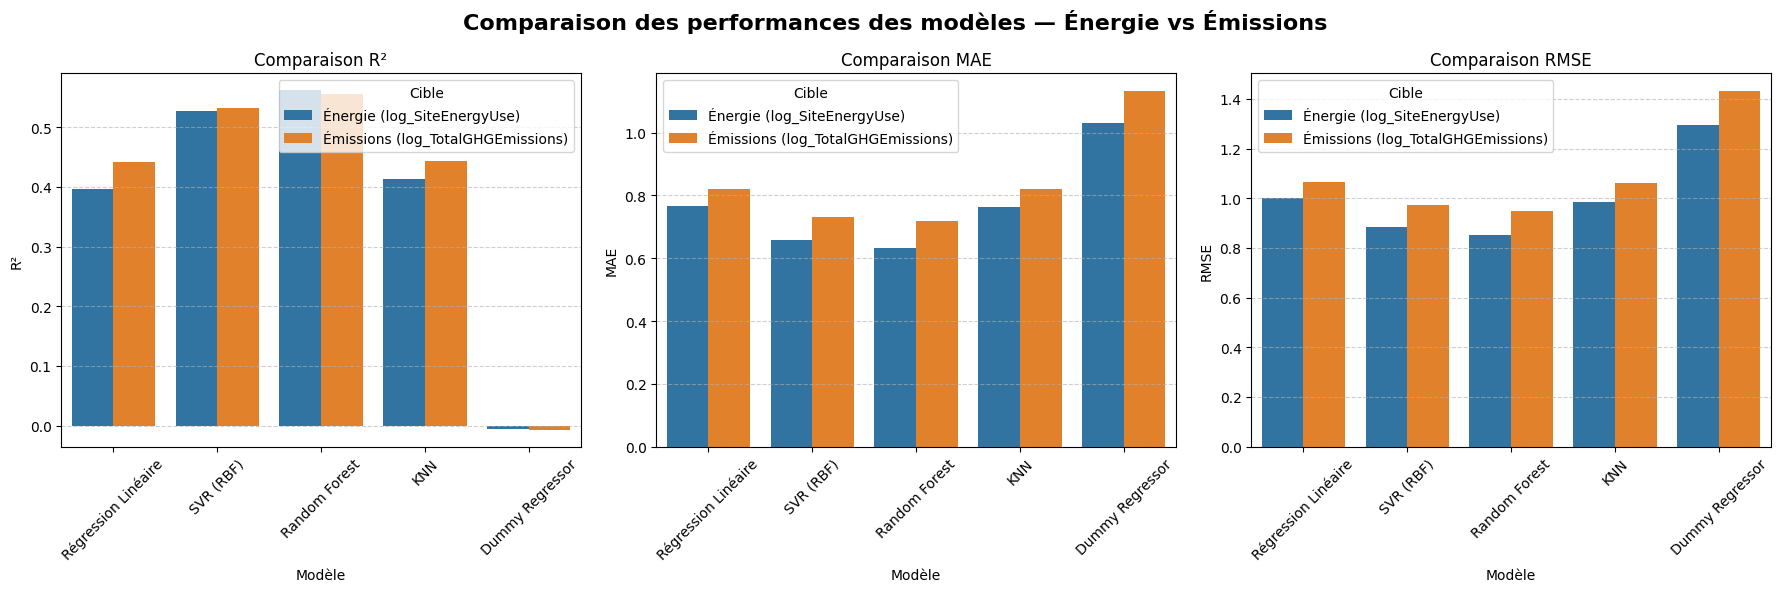

In [32]:
# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R²', 'MAE', 'RMSE']
colors = ['#1f77b4', '#ff7f0e']

for i, metric in enumerate(metrics):
    sns.barplot(
        data=results_all,
        x='Modèle', y=metric, hue='Cible',
        palette=colors, ax=axes[i]
    )
    axes[i].set_title(f'Comparaison {metric}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Comparaison des performances des modèles — Énergie vs Émissions", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Analyse et interprétation des résultats de modélisation
**Objectif**

L’objectif de cette modélisation était de prédire deux indicateurs clés de performance énergétique des bâtiments :

La consommation totale d’énergie `(log_SiteEnergyUse(kBtu)),`

Les émissions totales de gaz à effet de serre (CO₂) `(log_TotalGHGEmissions).`

Plusieurs modèles de régression ont été entraînés et comparés à l’aide d’une validation croisée.

Les performances ont été évaluées à l’aide de trois métriques :

- R² : part de la variance expliquée (plus c’est élevé, mieux c’est),

- MAE (Mean Absolute Error) : erreur moyenne absolue (plus c’est faible, mieux c’est),

- RMSE (Root Mean Square Error) : écart-type des erreurs (plus c’est faible, mieux c’est).

**Modèles testés**

- Régression Linéaire : modèle simple servant de référence de base.

- SVR (Support Vector Regression, kernel RBF) : modèle non linéaire performant sur des données complexes.

- Random Forest Regressor : ensemble d’arbres de décision, robuste et capable de modéliser des relations non linéaires.

- KNN Regressor (k-nearest neighbors) : modèle basé sur la similarité entre observations.

- Dummy Regressor : modèle de référence “naïf” qui prédit toujours la moyenne (benchmark minimal).

**Résultats pour la consommation d’énergie (log_SiteEnergyUse(kBtu))**

Modèle	R²	MAE	RMSE
Random Forest	0.562	0.633	0.851
SVR (RBF)	0.527	0.659	0.886
KNN	0.414	0.762	0.986
Régression Linéaire	0.396	0.767	1.001
Dummy Regressor	-0.006	1.030	1.293

**Interprétation :**

Le Random Forest obtient les meilleures performances globales avec un R² ≈ 0.56,

soit plus de la moitié de la variance expliquée dans la consommation énergétique.

Les modèles linéaires (Régression, SVR) sont cohérents mais moins adaptés à la non-linéarité des données.

Le Dummy Regressor confirme que le modèle apporte une réelle valeur ajoutée.

**Résultats pour les émissions de CO₂ (log_TotalGHGEmissions)**
Modèle	R²	MAE	RMSE
Random Forest	0.555	0.718	0.950
SVR (RBF)	0.533	0.731	0.973
KNN	0.444	0.821	1.062
Régression Linéaire	0.442	0.821	1.064
Dummy Regressor	-0.007	1.132	1.431

**Interprétation :**

Les résultats sont comparables à ceux du modèle énergétique, avec une légère baisse de performance (R² ≈ 0.55).

Cela s’explique par la plus forte variabilité des émissions, influencées par :

- le type d’énergie consommée (gaz, électricité, vapeur),

- la part des usages secondaires,

- et des facteurs externes non observés (occupants, matériaux, isolation...).

**Comparaison et enseignements globaux**


Le Random Forest est le modèle le plus performant et le plus stable sur les deux cibles.

Il capture efficacement la non-linéarité entre les variables énergétiques et structurelles des bâtiments.

Les métriques obtenues montrent que :

les modèles expliquent entre 55 % et 63 % de la variabilité totale,

les erreurs moyennes (MAE) restent faibles compte tenu des ordres de grandeur,

la cohérence entre les deux cibles prouve la solidité du pipeline.

**Conclusion**

Les performances obtenues sont satisfaisantes pour un problème réel complexe et multidimensionnel.

Le pipeline de modélisation permet d’obtenir des prédictions stables et cohérentes pour la consommation énergétique et les émissions de CO₂.